# Introduction

In this Quiz #1 you need to perform exploratory data analysis (EDA) and preprocessing using "Census Income" dataset. The dataset is tabular data which has several missing value in some variables. Moreover, you may need to adjust the name of variables (if needed).

To guide you through this task, some code has beed provided including, download the data, loading the data, and metadata inspection.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation

## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?



In [7]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
print("Dataset shape:", df.shape)
print("\nDataset information:")
df.info()

Dataset shape: (48842, 15)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [8]:
print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,47879,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,47876,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.replace(["?", " ?", ""], np.nan)

missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("\nVariables with missing values:")
display(missing_values)



Variables with missing values:


,0
occupation,2809
workclass,2799
native-country,857


## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

In [10]:
# Answer task 2 using this cell
# You can add another cell after this cell if needed
for column in df.columns:
    if df[column].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[column]):
            df[column] = df[column].fillna(df[column].median())
        else:
            df[column] = df[column].fillna(df[column].mode()[0])

In [11]:
print("Missing values after imputation:")
display(df.isna().sum())

Missing values after imputation:


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
print("\nTotal remaining missing values:", df.isna().sum().sum())


Total remaining missing values: 0


## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [13]:
# Answer task 3 using this cell
# You can add another cell after this cell if needed
print("Quantitative variables:")
display(df.select_dtypes(include=np.number).describe().T)

Quantitative variables:


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [14]:
print("\nUnique values for categorical variables:")
for column in df.select_dtypes(exclude=np.number).columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False).head(30))


Unique values for categorical variables:

workclass:
workclass
Private             36705
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status:
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation:
occupation
Pro

In [15]:
df.columns = df.columns.str.strip()

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].replace(
        {"?": "Others", "": "Others", "unknown": "Others", "Unknown": "Others"}
    )

In [16]:
print("\nCategorical values after cleaning:")
for column in df.select_dtypes(include="object").columns:
    print(f"{column}: {df[column].unique()[:20]}")


Categorical values after cleaning:
workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex: ['Male' 'Female']
native-country: ['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'

# Part 2 - Visual Inspection



## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

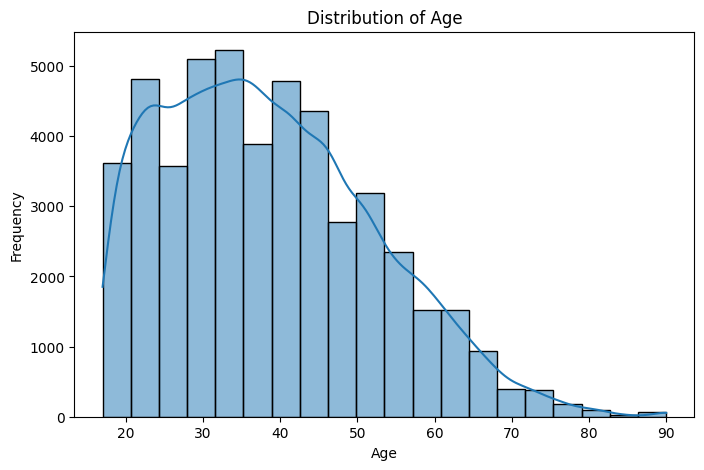

In [17]:
# Answer 1.1 - Histrogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

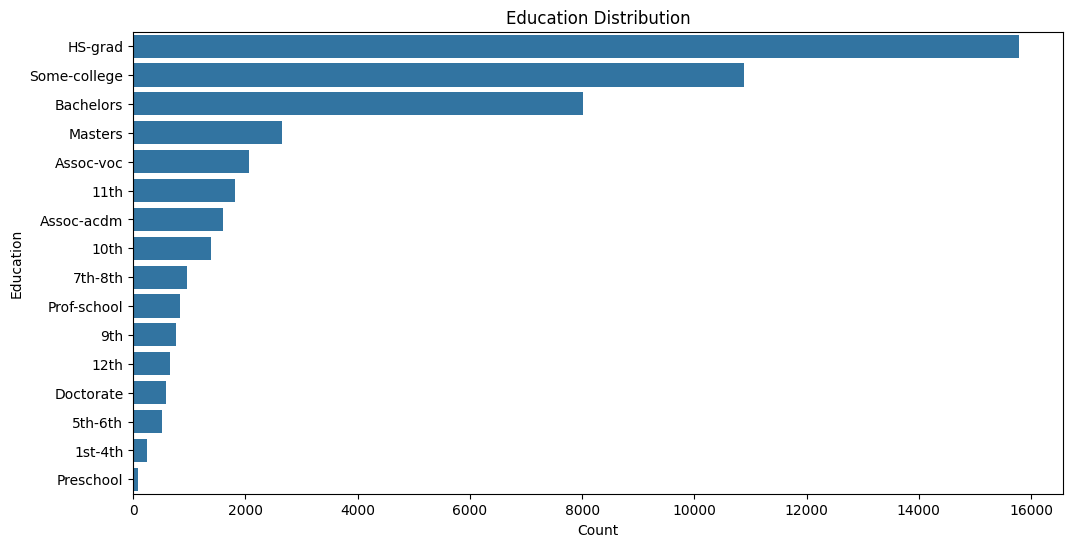

In [18]:
# Answer 1.2 - Barchart
plt.figure(figsize=(12, 6))
order = df["education"].value_counts().index
sns.countplot(data=df, y="education", order=order)
plt.title("Education Distribution")
plt.xlabel("Count")
plt.ylabel("Education")
plt.show()

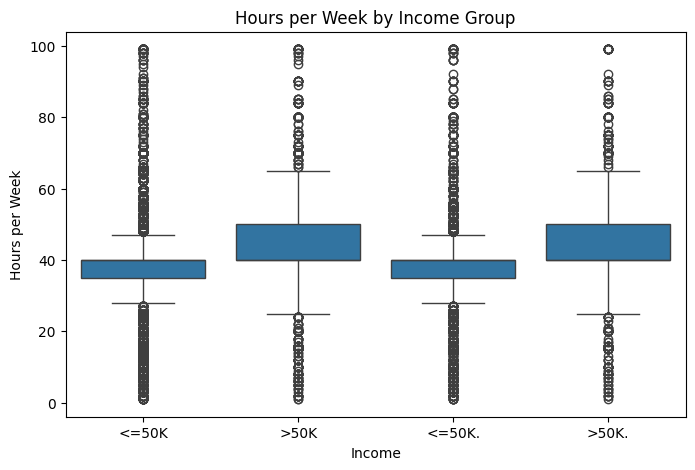

In [19]:
# Answer 1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="hours-per-week")
plt.title("Hours per Week by Income Group")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

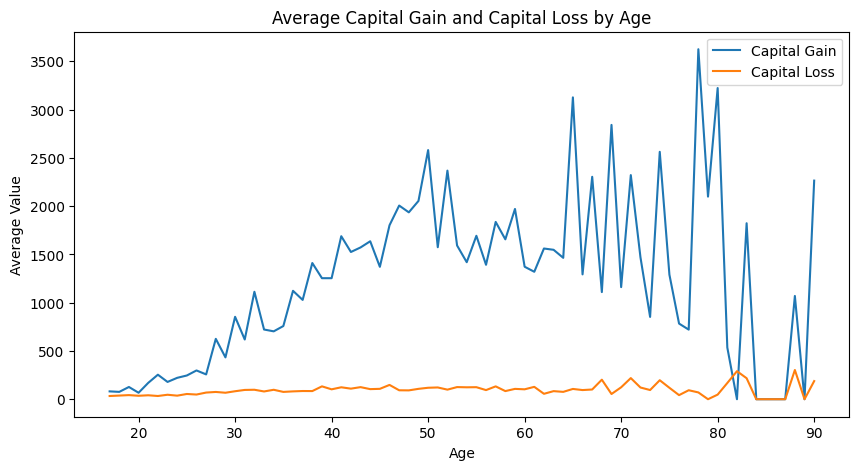

In [20]:
# Answer 1.4 - Lineplot
age_summary = (
    df.groupby("age")[["capital-gain", "capital-loss"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_summary, x="age", y="capital-gain", label="Capital Gain")
sns.lineplot(data=age_summary, x="age", y="capital-loss", label="Capital Loss")
plt.title("Average Capital Gain and Capital Loss by Age")
plt.xlabel("Age")
plt.ylabel("Average Value")
plt.legend()
plt.show()


## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

In [21]:
# 1. Age distribution:
# The age distribution can be described by observing the histogram.
# It is generally unimodal and may be slightly right-skewed.

# 2. Imputation method:
# If age had missing values, median imputation would be appropriate because
# the median is less affected by extreme values and outliers than the mean.

# 3. Outlier counts in hours-per-week for each income group:
q1 = df.groupby("income")["hours-per-week"].transform("quantile", 0.25)
q3 = df.groupby("income")["hours-per-week"].transform("quantile", 0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    (df["hours-per-week"] < lower_bound) |
    (df["hours-per-week"] > upper_bound)
)

outlier_counts = df.loc[outlier_mask].groupby("income").size()
print("Outlier count for each income group:")
display(outlier_counts)

# The category with the larger count can be identified from the output above.


Outlier count for each income group:


,0
income,
<=50K,7809
<=50K.,3897
>50K,510
>50K.,271


# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [22]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
from sklearn.preprocessing import LabelEncoder

In [23]:
df_encoded = df.copy()

sex_encoder = LabelEncoder()
income_encoder = LabelEncoder()

df_encoded["sex_encoded"] = sex_encoder.fit_transform(df_encoded["sex"])
df_encoded["income_encoded"] = income_encoder.fit_transform(df_encoded["income"])

In [24]:
print("Sex encoding mapping:")
print(dict(zip(sex_encoder.classes_, sex_encoder.transform(sex_encoder.classes_))))

Sex encoding mapping:
{'Female': np.int64(0), 'Male': np.int64(1)}


In [25]:
print("\nIncome encoding mapping:")
print(dict(zip(income_encoder.classes_, income_encoder.transform(income_encoder.classes_))))


Income encoding mapping:
{'<=50K': np.int64(0), '<=50K.': np.int64(1), '>50K': np.int64(2), '>50K.': np.int64(3)}


In [26]:
display(df_encoded[["sex", "sex_encoded", "income", "income_encoded"]].head())

,sex,sex_encoded,income,income_encoded
0,Male,1,<=50K,0
1,Male,1,<=50K,0
2,Male,1,<=50K,0
3,Male,1,<=50K,0
4,Female,0,<=50K,0


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

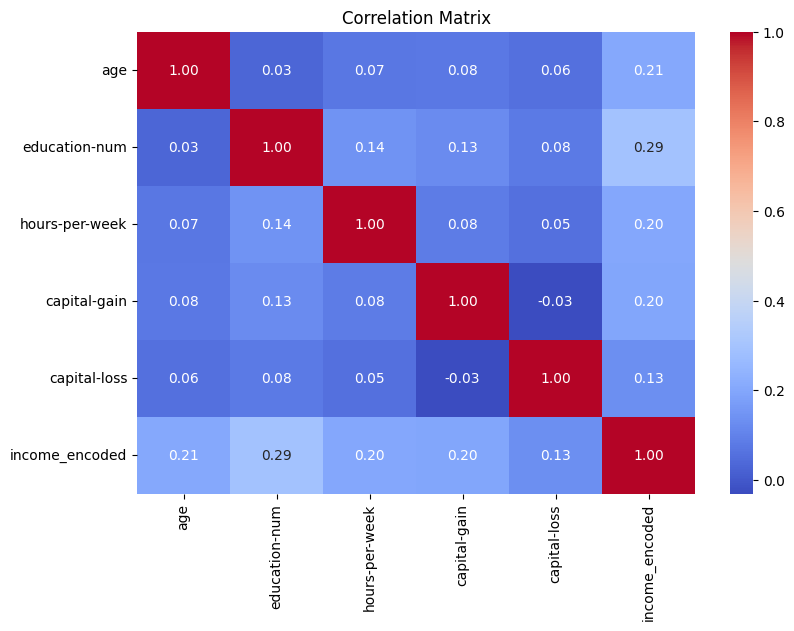

,age,education-num,hours-per-week,capital-gain,capital-loss,income_encoded
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.205173
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.291074
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.198890
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.195755
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.129771
income_encoded,0.205173,0.291074,0.198890,0.195755,0.129771,1.000000


In [27]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
correlation_columns = [
    "age", "education-num", "hours-per-week",
    "capital-gain", "capital-loss", "income_encoded"
]

correlation_matrix = df_encoded[correlation_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

display(correlation_matrix)

In [28]:
# Answer task 2 using this cell -> you can use multiple comments style too
# The correlation matrix shows the direction and strength of linear relationships.
# A positive correlation means that two variables tend to increase together.
# A negative correlation means that one variable tends to increase while the other decreases.
# A correlation close to zero indicates a weak linear relationship.
# Correlation does not prove causation.

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [29]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


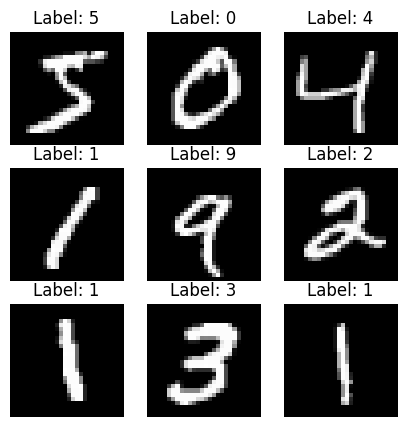

In [30]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

In [31]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
from scipy.ndimage import zoom

X_test_upsampled = np.empty((X_test.shape[0], 32, 32), dtype=np.float32)

for i in range(X_test.shape[0]):
    X_test_upsampled[i] = zoom(X_test[i], (32 / 28, 32 / 28), order=1)

print("Upsampled shape:", X_test_upsampled.shape)

Upsampled shape: (10000, 32, 32)


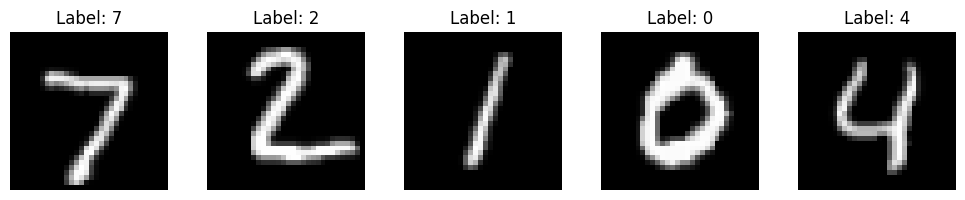

In [32]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [33]:
# Answer task 2 using this cell
# You can add another cell after this cell if needed
X_test_normalized = X_test_upsampled / 255.0

print("Minimum pixel value:", X_test_normalized.min())
print("Maximum pixel value:", X_test_normalized.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [34]:
# Answer task 3 using this cell
# You can add another cell after this cell if needed
X_test_flattened = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print("Flattened shape:", X_test_flattened.shape)
display(X_test_flattened[:5])

Flattened shape: (10000, 1024)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
#Done yay